In [2]:
library(tidyverse)
library(dplyr)

In [3]:
color_dict = c(
    "CellFlow"= "#B12F8C",
    "Mean model 1"= "#8F97A8",
    "Mean model 2"= "#566573",
    "Identity"="#BDBDBD",
    "Closest embedding" = "#E0E0E0")

In [4]:
output_dir <- "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc_new_donor/benchmark"

In [9]:
df <- read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_donor.csv")

New names:
• `` -> `...1`
Rows: 12216 Columns: 179
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (10): ...1, Unnamed: 0, predicted_deg_genes, wandb_name, cytokine_in_t...
dbl  (167): mean_decoded_r_sq_per_cell_type, mean_e_distance_per_cell_type, ...
lgl    (1): new_run
dttm   (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
df$method <- factor(df$method, 
                                levels = c("id", "m1", "m2", "cl_emb", "cf"),
                                labels = c("Identity", "Mean model 1", "Mean model 2", "Closest embedding", "CellFlow"))  # Correct factorization

df$num_cytokines_in_train <- as.character(df$num_cytokines_in_train)

df$num_cytokines_in_train <- factor(df$num_cytokines_in_train, 
                                    levels = sort(as.numeric(unique(df$num_cytokines_in_train))))



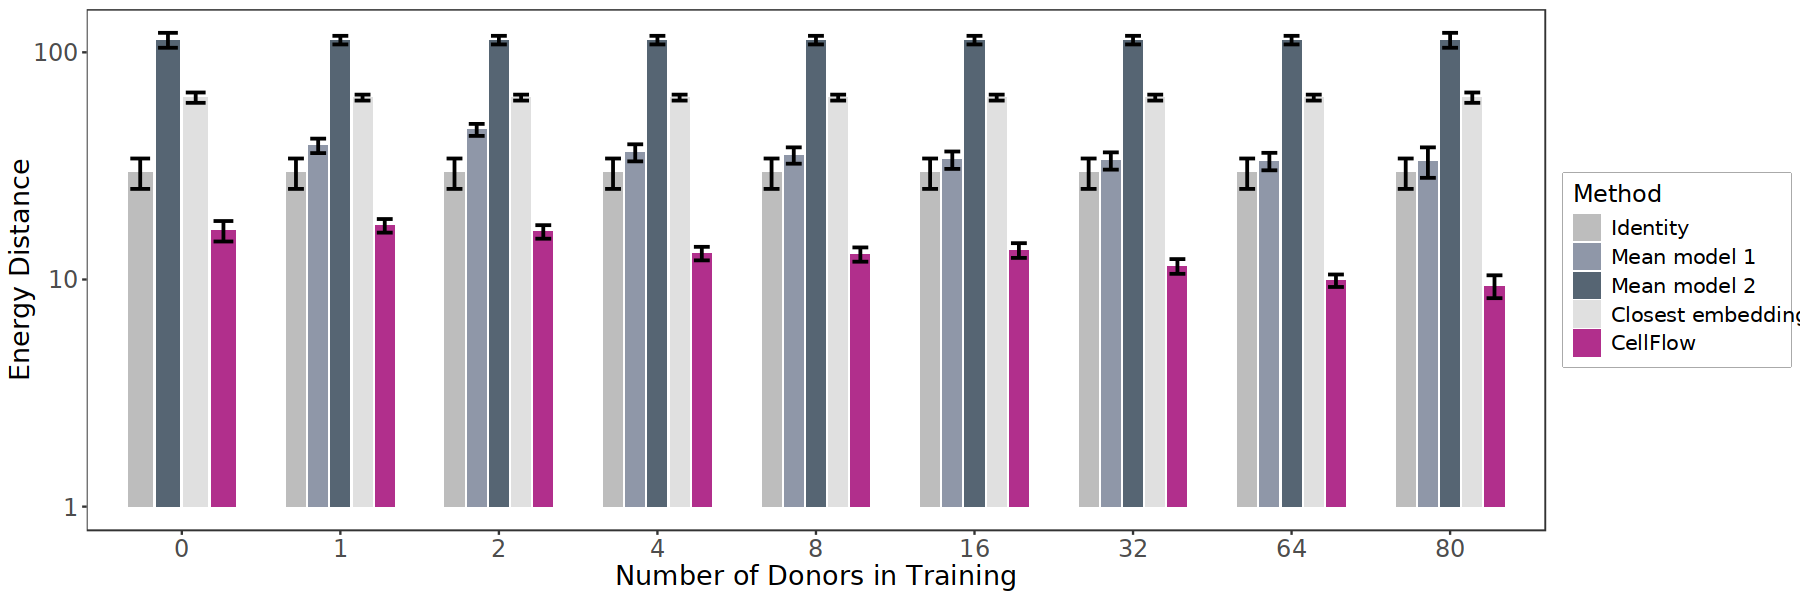

In [11]:
options(repr.plot.width = 15, repr.plot.height = 5)

df_summary <- df %>%
  group_by(num_cytokines_in_train, method) %>%
  summarise(
    mean_ood_e_distance = mean(ood_e_distance, na.rm = TRUE),
    se = sd(ood_e_distance, na.rm = TRUE) / sqrt(n()),  # Standard error
    .groups = 'drop'
  )

p <- ggplot(df_summary, aes(x=num_cytokines_in_train, y=mean_ood_e_distance, fill=method)) +
  geom_bar(
    stat="identity", 
    position=position_dodge(0.7), 
    width=0.6  # Bar width
  ) +
  geom_errorbar(
    aes(ymin = mean_ood_e_distance - se, ymax = mean_ood_e_distance + se),
    position=position_dodge(0.7),  # Align error bars with bars
    width=0.5,  # Width of error bar caps
    linewidth=0.8,
  ) +
  labs(
    x="Number of Donors in Training",
    y="Energy Distance",
    fill="Method"
  ) +
scale_y_log10() +
  scale_fill_manual(values=color_dict) +  # Replace with your actual color dictionary
  theme_bw() +
  theme(
    axis.title.x = element_text(size=16),
    axis.title.y = element_text(size=16),
    axis.text.x = element_text(size=14),
    axis.text.y = element_text(size=14),
    legend.title = element_text(size=14),
    legend.text = element_text(size=12),
    legend.position = "right",
    legend.box.background = element_rect(color="black"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )
p


In [12]:
ggsave(file.path(output_dir, "E_distance.pdf"), plot = p, device = "pdf",width = 15, height = 5)

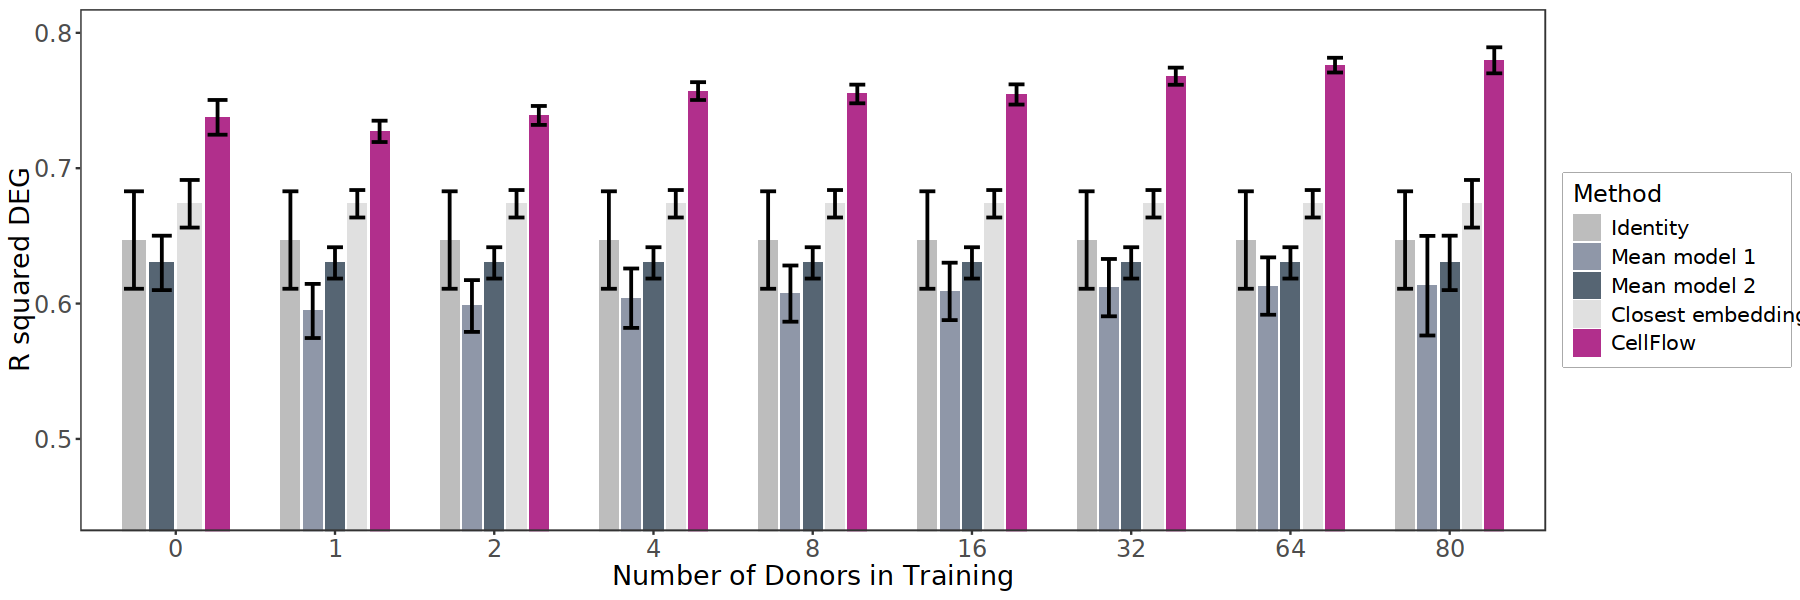

In [13]:
df_summary <- df %>%
  group_by(num_cytokines_in_train, method) %>%
  summarise(
    mean_mean_deg_r_sq_per_cell_type = mean(mean_deg_r_sq_per_cell_type, na.rm = TRUE),
    se = sd(mean_deg_r_sq_per_cell_type, na.rm = TRUE) / sqrt(n()),  # Standard error
    .groups = 'drop'
  )


p <- ggplot(df_summary, aes(x=num_cytokines_in_train, y=mean_mean_deg_r_sq_per_cell_type, fill=method)) +
  geom_bar(
    stat="identity", 
    position=position_dodge(0.7), 
    width=0.6  # Bar width
  ) +
  geom_errorbar(
    aes(ymin = mean_mean_deg_r_sq_per_cell_type - se, ymax = mean_mean_deg_r_sq_per_cell_type + se),
    position=position_dodge(0.7),  # Align error bars with bars
    width=0.5,  # Width of error bar caps
    linewidth=0.8,
  ) +
  labs(
    x="Number of Donors in Training",
    y="R squared DEG",
    fill="Method"
  ) +
  scale_fill_manual(values=color_dict) +  # Replace with your actual color dictionary
  theme_bw() +
  theme(
    axis.title.x = element_text(size=16),
    axis.title.y = element_text(size=16),
    axis.text.x = element_text(size=14),
    axis.text.y = element_text(size=14),
    legend.title = element_text(size=14),
    legend.text = element_text(size=12),
    legend.position = "right",
    legend.box.background = element_rect(color="black"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  coord_cartesian(ylim = c(0.45, 0.8))  # Set y-axis limits without truncating data
p


In [14]:
ggsave(file.path(output_dir, "r_squared_deg.pdf"), plot = p, device = "pdf",width = 15, height = 5)